In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import time
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from transformers import (
    DeformableDetrConfig, 
    DeformableDetrForObjectDetection, 
    DeformableDetrImageProcessor
)
from PIL import Image
import matplotlib.pyplot as plt

# Ensure pycocotools is installed.
!python -c "import pycocotools" || pip install pycocotools
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Set device (e.g., Kaggle GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

2025-05-16 13:31:40.681142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747402300.908502      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747402300.982906      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 1. Helper Functions
Use Vectorized Division for Normalization: Instead of rebuilding a tensor from a list (which could introduce slight inconsistencies and rounding differences), we use vectorized arithmetic to compute the normalized box.\

Reduce the Right Shift Magnitude: In the right‐shift branch (action 1), we multiply the shift fraction by a factor (e.g. 0.8) to counterbalance the accumulation effect that systematically biases the box to the right.

In [2]:
def load_image(image_path):
    return Image.open(image_path).convert("RGB")

def compute_iou(boxA, boxB):
    # box format: [xmin, ymin, xmax, ymax]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

def convert_coco_bbox_to_xyxy(bbox):
    x, y, w, h = bbox
    return [x, y, x+w, y+h]

def get_candidate_embedding(outputs, candidate_idx):
    # Return candidate embedding from the last decoder hidden state.
    return outputs.decoder_hidden_states[-1][0, candidate_idx, :]

# build_state: returns normalized vector (5 values) optionally concatenated with candidate embedding.
def build_state(box, score, image_width, image_height, embedding=None):
    xmin, ymin, xmax, ymax = box.tolist()
    width = xmax - xmin
    height = ymax - ymin
    spatial = torch.tensor([
        xmin / image_width,
        ymin / image_height,
        width / image_width,
        height / image_height,
        score
    ], dtype=torch.float32, device=box.device)
    if embedding is not None:
        return torch.cat([spatial, embedding])
    else:
        return spatial

# apply_action: performs one action in normalized space then scales back.
def apply_action(box, action, image_width, image_height, shift_frac=0.005, scale_frac=0.05):
    # Use vectorized operations for consistent normalization.
    device = box.device
    dims = torch.tensor([image_width, image_height, image_width, image_height],
                        dtype=torch.float32, device=device)
    # Normalize box coordinates.
    norm_box = box / dims
    
    w = norm_box[2] - norm_box[0]
    h = norm_box[3] - norm_box[1]
    
    if action == 0:  # shift left
        norm_box[0] -= shift_frac
        norm_box[2] -= shift_frac
    elif action == 1:  # shift right (reduce the step size to avoid accumulation)
        norm_box[0] += shift_frac * 0.8
        norm_box[2] += shift_frac * 0.8
    elif action == 2:  # shift up
        norm_box[1] -= shift_frac
        norm_box[3] -= shift_frac
    elif action == 3:  # shift down
        norm_box[1] += shift_frac
        norm_box[3] += shift_frac
    elif action == 4:  # scale up
        norm_box[0] -= scale_frac * w
        norm_box[1] -= scale_frac * h
        norm_box[2] += scale_frac * w
        norm_box[3] += scale_frac * h
    elif action == 5:  # scale down
        norm_box[0] += scale_frac * w
        norm_box[1] += scale_frac * h
        norm_box[2] -= scale_frac * w
        norm_box[3] -= scale_frac * h
    elif action == 6:  # increase width
        norm_box[0] -= scale_frac * w
        norm_box[2] += scale_frac * w
    elif action == 7:  # decrease width
        norm_box[0] += scale_frac * w
        norm_box[2] -= scale_frac * w
    # Action 8 (STOP): no change.
    
    # Clamp values to [0, 1] to ensure valid normalized coordinates.
    norm_box = norm_box.clamp(0, 1)
    # Convert back to pixel coordinates.
    new_box = norm_box * dims
    return new_box


# 2. Load Pretrained Model and Define Datasets

In [3]:
# ------------------------------------------------------------------------------
# 1. Model and Processor Loading
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "SenseTime/deformable-detr"

# Load processor.
processor = DeformableDetrImageProcessor.from_pretrained(model_id)

# Download weights.
checkpoint_url = f"https://huggingface.co/{model_id}/resolve/main/pytorch_model.bin"
state_dict = torch.hub.load_state_dict_from_url(
    checkpoint_url, map_location="cpu", progress=True
)

# Instantiate model from config.
config = DeformableDetrConfig.from_pretrained(model_id)
model = DeformableDetrForObjectDetection(config)
model.load_state_dict(state_dict, strict=False, assign=True)
model.config.output_hidden_states = True  # Enable hidden states for embeddings.
model.to(device)
model.eval()

# ------------------------------------------------------------------------------
# 2. Dataset Setup (COCO training/validation and training subset)
# ------------------------------------------------------------------------------
transform = transforms.Compose([transforms.ToTensor()])

train_img_dir = "/kaggle/input/coco-2017-dataset/coco2017/train2017"
train_annFile = "/kaggle/input/coco-2017-dataset/coco2017/annotations/instances_train2017.json"
val_img_dir   = "/kaggle/input/coco-2017-dataset/coco2017/val2017"
val_annFile   = "/kaggle/input/coco-2017-dataset/coco2017/annotations/instances_val2017.json"

train_dataset = datasets.CocoDetection(root=train_img_dir, annFile=train_annFile, transform=transform)
val_dataset   = datasets.CocoDetection(root=val_img_dir, annFile=val_annFile, transform=transform)

# CocoSubset to load a specific training subset.
class CocoSubset(datasets.CocoDetection):
    def __init__(self, root, annFile, subset_info, transform=None):
        super(CocoSubset, self).__init__(root, annFile, transform)
        subset_ids = {item["id"] for item in subset_info}
        self.ids = [img_id for img_id in self.ids if img_id in subset_ids]

subset_json_path = "/kaggle/input/low-map-subset/low_mAP_medium_small_subset.json"
with open(subset_json_path, "r") as f:
    subset_info = json.load(f)
subset_train_dataset = CocoSubset(train_img_dir, train_annFile, subset_info, transform=transform)
subset_train_loader = DataLoader(subset_train_dataset, batch_size=2, shuffle=True,
                                 collate_fn=lambda x: tuple(zip(*x)))
print(f"Subset training dataset has {len(subset_train_dataset)} images.")

preprocessor_config.json:   0%|          | 0.00/305 [00:00<?, ?B/s]

Downloading: "https://huggingface.co/SenseTime/deformable-detr/resolve/main/pytorch_model.bin" to /root/.cache/torch/hub/checkpoints/pytorch_model.bin
100%|██████████| 153M/153M [00:00<00:00, 334MB/s]


config.json:   0%|          | 0.00/4.54k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

loading annotations into memory...
Done (t=20.56s)
creating index...
index created!
loading annotations into memory...
Done (t=0.69s)
creating index...
index created!
loading annotations into memory...
Done (t=15.55s)
creating index...
index created!
Subset training dataset has 7654 images.


In [4]:
# print(model.config.d_model)

In [5]:
"""
# 3. Create a Subset JSON (Low mAP for Medium/Small)
For our purposes we iterate over a limited number (e.g., 10000) of training images, computing an average IoU for ground-truth boxes (with area < 9216, i.e., small/medium).\
Images where the average IoU is below a threshold (e.g., 0.5) are saved into a subset JSON.
"""

# subset_details = []
# processed_images = 0
# subset_threshold = 0.5  # Average IoU threshold.
# max_process = 10000       # Process at most 100 images.

# print("Generating subset (low mAP on medium/small objects) from training set...")
# for images, targets in train_loader:
#     for image, target in zip(images, targets):
#         if processed_images >= max_process:
#             break
#         pil_img = transforms.ToPILImage()(image)
#         image_width, image_height = pil_img.size

#         # Run baseline detection.
#         inputs = processor(images=pil_img, return_tensors="pt").to(device)
#         with torch.no_grad():
#             outputs = model(**inputs)
#         pred_boxes = outputs.pred_boxes[0].clone()
#         pred_boxes[:, [0, 2]] *= image_width
#         pred_boxes[:, [1, 3]] *= image_height

#         # Filter GT annotations for small/medium objects (area < 9216).
#         gm_boxes = []
#         for ann in target:
#             if "bbox" in ann and "area" in ann and ann["area"] < 9216:
#                 gm_boxes.append(convert_coco_bbox_to_xyxy(ann["bbox"]))
#         if len(gm_boxes) == 0:
#             processed_images += 1
#             continue

#         # Compute maximum IoU for each GT box.
#         iou_list = []
#         for gt_box in gm_boxes:
#             max_iou = 0.0
#             for box in pred_boxes:
#                 iou = compute_iou(gt_box, box.tolist())
#                 max_iou = max(max_iou, iou)
#             iou_list.append(max_iou)
#         avg_iou = float(np.mean(iou_list)) if iou_list else 0.0

#         if avg_iou < subset_threshold:
#             if len(target) > 0:
#                 image_id = target[0].get("image_id", processed_images)
#             else:
#                 image_id = processed_images
#             if image_id in train_dataset.coco.imgs:
#                 info = train_dataset.coco.imgs[image_id]
#             else:
#                 info = {"id": image_id, "file_name": f"{image_id:012d}.jpg",
#                         "width": image_width, "height": image_height}
#             subset_details.append(info)
#         processed_images += 1
#     if processed_images >= max_process:
#         break

# subset_json_path = "low_mAP_medium_small_subset.json"
# with open(subset_json_path, "w") as f:
#     json.dump(subset_details, f)
# print(f"Subset generated with {len(subset_details)} images (out of {processed_images}) saved to {subset_json_path}")

'\n# 3. Create a Subset JSON (Low mAP for Medium/Small)\nFor our purposes we iterate over a limited number (e.g., 10000) of training images, computing an average IoU for ground-truth boxes (with area < 9216, i.e., small/medium).Images where the average IoU is below a threshold (e.g., 0.5) are saved into a subset JSON.\n'

In [6]:
"""# 4. Create a Subset Training Dataset Using the JSON """
# # Define the path to the uploaded low mAP JSON file.
# subset_json_path = "/kaggle/input/low-map-subset/low_mAP_medium_small_subset.json"

# # Load the JSON file containing the subset details.
# with open(subset_json_path, "r") as f:
#     subset_details = json.load(f)
# print(f"Loaded subset JSON with {len(subset_details)} image entries.")

# # Create a custom CocoDetection subset class that uses the loaded image IDs.
# class CocoSubset(datasets.CocoDetection):
#     def __init__(self, root, annFile, subset_info, transform=None):
#         super(CocoSubset, self).__init__(root, annFile, transform)
#         # Extract the image IDs from the subset_info.
#         subset_ids = {item["id"] for item in subset_info}
#         # Filter the dataset image IDs to include only those in the subset.
#         self.ids = [img_id for img_id in self.ids if img_id in subset_ids]

# # Now instantiate your subset training dataset using the loaded JSON.
# subset_train_dataset = CocoSubset(train_img_dir, train_annFile, subset_details, transform=transform)
# subset_train_loader = DataLoader(
#     subset_train_dataset,
#     batch_size=2,
#     shuffle=True,
#     collate_fn=lambda x: tuple(zip(*x))
# )
# print(f"Subset training dataset loaded with {len(subset_train_dataset)} images.")

'# 4. Create a Subset Training Dataset Using the JSON '

# 5. Define the RL Agent (Deep Q-Network)
Assume candidate embedding dimension = 256, so total input dimension = 5 + 256 = 261.
Treat the input as a 1D "image" with 1 channel and length = 261.

In [7]:
input_dim = 5 + 256
action_dim = 9

class DQNCNNAgent(nn.Module):
    def __init__(self, input_dim, action_dim):
        super(DQNCNNAgent, self).__init__()
        # The input is reshaped to (batch, channels=1, length=input_dim)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1)
        # Calculate the new length after two conv layers without padding.
        conv_output_length = input_dim - (3 - 1)*2  # each conv reduces length by (kernel_size-1)
        self.fc1 = nn.Linear(64 * conv_output_length, 128)
        self.fc2 = nn.Linear(128, action_dim)
        
    def forward(self, state):
        # state: (batch, input_dim) --> reshape to (batch, 1, input_dim)
        x = state.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

agent = DQNCNNAgent(input_dim=input_dim, action_dim=action_dim).to(device)
optimizer_rl = optim.Adam(agent.parameters(), lr=1e-4)

# 6. RL Training on the Subset

In [8]:
# Training hyperparameters.
MAX_STEPS = 3
STOP_ACTION = 8
num_rl_iterations = 5    # For demonstration.
gamma = 0.9
epsilon = 0.2           # Initial exploration rate.
reward_scale = 1.0      # States are normalized.
max_batches = 300       # Limit batches per iteration.

# Metrics tracking lists.
training_losses = []
cumulative_rewards = []        # Sum of rewards.
moving_avg_rewards = []        # Average reward per update.
avg_temporal_errors = []       # Average SmoothL1 loss.
exploration_rates = []         # Epsilon per iteration.
success_rates = []             # Candidate success rate.
iteration_times = []           # Training time per iteration (seconds).
avg_q_values = []              # Average predicted Q value.

print("Starting RL training (CNN DQN with candidate embeddings)...")

for iteration in range(num_rl_iterations):
    iter_start_time = time.time()
    cumulative_loss = 0.0
    count_updates = 0
    iter_cum_reward = 0.0
    reward_steps = 0
    candidate_success = 0
    candidate_total = 0
    q_val_sum = 0.0

    for batch_idx, (images, targets) in enumerate(subset_train_loader):
        if batch_idx >= max_batches:
            break
        for image, target in zip(images, targets):
            pil_img = transforms.ToPILImage()(image)
            image_width, image_height = pil_img.size

            inputs = processor(images=pil_img, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**inputs)
            target_sizes = torch.tensor([pil_img.size[::-1]], device=device)
            post_results = processor.post_process_object_detection(outputs, threshold=0.05, target_sizes=target_sizes)[0]
            pred_boxes = post_results["boxes"]
            pred_scores = post_results["scores"]

            # Filter ground-truth for small/medium objects.
            gt_boxes = []
            for ann in target:
                if "bbox" in ann and "area" in ann and ann["area"] < 9216:
                    gt_boxes.append(convert_coco_bbox_to_xyxy(ann["bbox"]))
            if not gt_boxes:
                continue
            gt_boxes = [torch.tensor(b, device=device, dtype=torch.float32) for b in gt_boxes]

            for i, score in enumerate(pred_scores):
                score_val = score.item()
                if score_val < 0.05 or score_val > 0.9:
                    continue
                box = pred_boxes[i]
                best_iou = 0.0
                best_gt = None
                for gt_box in gt_boxes:
                    iou_val = compute_iou(box.tolist(), gt_box.tolist())
                    if iou_val > best_iou:
                        best_iou = iou_val
                        best_gt = gt_box
                if best_gt is None:
                    continue

                # For success rate: record initial IoU.
                initial_box = box.clone()
                baseline_iou = compute_iou(initial_box.tolist(), best_gt.tolist())

                # Extract candidate embedding.
                candidate_embedding = get_candidate_embedding(outputs, i)
                # Build enriched state: 5 normalized features plus candidate_embedding.
                state = torch.cat([build_state(box, score_val, image_width, image_height), candidate_embedding])
                for step in range(MAX_STEPS):
                    # ε-greedy: choose random action or best action.
                    if np.random.rand() < epsilon:
                        action = np.random.choice(9)
                    else:
                        q_vals = agent(state.unsqueeze(0))
                        action = torch.argmax(q_vals, dim=1).item()
                    if action == STOP_ACTION:
                        break
                    new_box = apply_action(box, action, image_width, image_height)
                    state = torch.cat([build_state(new_box, score_val, image_width, image_height), candidate_embedding])
                    with torch.no_grad():
                        next_q = torch.max(agent(state.unsqueeze(0))).item()
                    reward = reward_scale * compute_iou(new_box.tolist(), best_gt.tolist())
                    iter_cum_reward += reward
                    reward_steps += 1
                    target_q = reward + gamma * next_q
                    predicted_q = agent(state.unsqueeze(0))[0][action]
                    loss = F.smooth_l1_loss(predicted_q, torch.tensor(target_q, device=device))
                    cumulative_loss += loss
                    count_updates += 1
                    q_val_sum += predicted_q.item()
                    box = new_box  # update candidate bounding box
                final_iou = compute_iou(box.tolist(), best_gt.tolist())
                candidate_total += 1
                if final_iou > baseline_iou:
                    candidate_success += 1
        torch.cuda.empty_cache()

    iteration_time = time.time() - iter_start_time
    avg_loss = cumulative_loss.item() / count_updates if count_updates > 0 else 0
    avg_reward = iter_cum_reward / reward_steps if reward_steps > 0 else 0
    avg_q = q_val_sum / count_updates if count_updates > 0 else 0
    success_rate = candidate_success / candidate_total if candidate_total > 0 else 0

    training_losses.append(avg_loss)
    cumulative_rewards.append(iter_cum_reward)
    moving_avg_rewards.append(avg_reward)
    avg_temporal_errors.append(avg_loss)
    exploration_rates.append(epsilon)
    success_rates.append(success_rate)
    iteration_times.append(iteration_time)
    avg_q_values.append(avg_q)

    optimizer_rl.zero_grad()
    cumulative_loss.backward()
    torch.nn.utils.clip_grad_norm_(agent.parameters(), 1.0)
    optimizer_rl.step()

    epsilon = max(0.05, epsilon*0.99)
    print(f"Iteration {iteration+1}: Avg loss = {avg_loss:.4f}, Avg reward = {avg_reward:.4f}, Success rate = {success_rate:.4f}, Avg Q = {avg_q:.4f}, Epsilon = {epsilon:.4f}, Time = {iteration_time:.2f}s, Updates = {count_updates}")

# Save the trained DQN CNN agent.
agent_save_path = "cnn_dqn_agent_sensetime_deformable_detr.pth"
torch.save(agent.state_dict(), agent_save_path)
print(f"Trained agent saved to {agent_save_path}")

Starting RL training (CNN DQN with candidate embeddings)...
Iteration 1: Avg loss = 0.0890, Avg reward = 0.3068, Success rate = 0.3028, Avg Q = 0.0938, Epsilon = 0.1980, Time = 323.15s, Updates = 86679
Iteration 2: Avg loss = 0.1044, Avg reward = 0.3091, Success rate = 0.3094, Avg Q = 0.3825, Epsilon = 0.1960, Time = 327.04s, Updates = 87171
Iteration 3: Avg loss = 0.1244, Avg reward = 0.3027, Success rate = 0.3097, Avg Q = 0.6783, Epsilon = 0.1941, Time = 318.86s, Updates = 88122
Iteration 4: Avg loss = 0.1592, Avg reward = 0.3110, Success rate = 0.3155, Avg Q = 0.9913, Epsilon = 0.1921, Time = 319.10s, Updates = 87624
Iteration 5: Avg loss = 0.1955, Avg reward = 0.3100, Success rate = 0.3137, Avg Q = 1.3132, Epsilon = 0.1902, Time = 315.94s, Updates = 86719
Trained agent saved to cnn_dqn_agent_sensetime_deformable_detr.pth


# 7. Evaluation on the Validation Set

In [9]:
max_eval = 100
subset_indices = list(range(max_eval))
subset_val_dataset = Subset(val_dataset, subset_indices)
subset_val_loader = DataLoader(subset_val_dataset, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

results_baseline = []  # Baseline detections.
results_rl = []        # RL-refined detections.

cocoGt = COCO(val_annFile)
valid_img_ids = set(cocoGt.getImgIds())
print("Total valid image IDs in ground-truth:", len(valid_img_ids))
print(f"Evaluating on {max_eval} images from the validation set...")

# For evaluation, we use a simple greedy refine_box function (without CNN gradient update).
def refine_box(box, score, image_width, image_height, candidate_embedding, max_steps=MAX_STEPS):
    # Create enriched state by concatenating the candidate embedding.
    state = torch.cat([build_state(box, score, image_width, image_height), candidate_embedding])
    for step in range(max_steps):
        q_vals = agent(state.unsqueeze(0))
        action = torch.argmax(q_vals, dim=1).item()
        if action == STOP_ACTION:
            break
        box = apply_action(box, action, image_width, image_height)
        state = torch.cat([build_state(box, score, image_width, image_height), candidate_embedding])
    return box

for images, targets in subset_val_loader:
    for image, target in zip(images, targets):
        if len(target) > 0 and "image_id" in target[0]:
            image_id = target[0]["image_id"]
        else:
            image_id = -1
        if image_id not in valid_img_ids:
            continue

        pil_img = transforms.ToPILImage()(image)
        image_width, image_height = pil_img.size

        inputs = processor(images=pil_img, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        target_sizes = torch.tensor([pil_img.size[::-1]], device=device)
        post_results = processor.post_process_object_detection(outputs, threshold=0.05, target_sizes=target_sizes)[0]
        pred_boxes = post_results["boxes"]
        pred_scores = post_results["scores"]
        pred_labels = post_results["labels"]

        num_preds = pred_boxes.shape[0]
        for i in range(num_preds):
            score_val = pred_scores[i].item()
            if score_val < 0.05:
                continue
            box = pred_boxes[i]
            width_val = (box[2]-box[0]).item()
            height_val = (box[3]-box[1]).item()
            if width_val <= 0 or height_val <= 0:
                continue
            bbox_baseline = [box[0].item(), box[1].item(), width_val, height_val]
            detection_baseline = {
                "image_id": image_id,
                "category_id": int(pred_labels[i].item()),
                "bbox": bbox_baseline,
                "score": score_val
            }
            results_baseline.append(detection_baseline)

            candidate_embedding = get_candidate_embedding(outputs, i)
            refined_box = refine_box(box, score_val, image_width, image_height, candidate_embedding, max_steps=MAX_STEPS)
            refined_width = (refined_box[2]-refined_box[0]).item()
            refined_height = (refined_box[3]-refined_box[1]).item()
            if refined_width <= 0 or refined_height <= 0:
                continue
            bbox_refined = [refined_box[0].item(), refined_box[1].item(), refined_width, refined_height]
            detection_rl = {
                "image_id": image_id,
                "category_id": int(pred_labels[i].item()),
                "bbox": bbox_refined,
                "score": score_val
            }
            results_rl.append(detection_rl)

with open("results_baseline.json", "w") as f:
    json.dump(results_baseline, f)
with open("results_rl.json", "w") as f:
    json.dump(results_rl, f)
print("Detection results saved.")

cocoDt_baseline = cocoGt.loadRes("results_baseline.json")
cocoEval_baseline = COCOeval(cocoGt, cocoDt_baseline, iouType="bbox")
cocoEval_baseline.evaluate()
cocoEval_baseline.accumulate()
print("\nCOCO Evaluation Metrics for Baseline Deformable DETR:")
cocoEval_baseline.summarize()

cocoDt_rl = cocoGt.loadRes("results_rl.json")
cocoEval_rl = COCOeval(cocoGt, cocoDt_rl, iouType="bbox")
cocoEval_rl.evaluate()
cocoEval_rl.accumulate()
print("\nCOCO Evaluation Metrics for Deformable DETR + RL:")
cocoEval_rl.summarize()

loading annotations into memory...
Done (t=0.41s)
creating index...
index created!
Total valid image IDs in ground-truth: 5000
Evaluating on 100 images from the validation set...
Detection results saved.
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.84s).
Accumulating evaluation results...
DONE (t=1.32s).

COCO Evaluation Metrics for Baseline Deformable DETR:
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.016
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.013
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.009
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.017
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=

# 8. Build and Show a Metrics Table and Visualizations
Extract key metrics from cocoEval.stats; conventionally:\
stats[0]=mAP@[.50:.95], [1]=AP@50, [2]=AP@75, [3]=AP_small, [8]=AR@100


Summary Metrics Table:
          Metric  Baseline   With RL  Difference
0  mAP@[.50:.95]  0.012059  0.008573   -0.003486
1          AP@50  0.016014  0.013397   -0.002617
2          AP@75  0.012919  0.008843   -0.004076
3       AP_small  0.008716  0.001840   -0.006876
4         AR@100  0.011362  0.007848   -0.003513


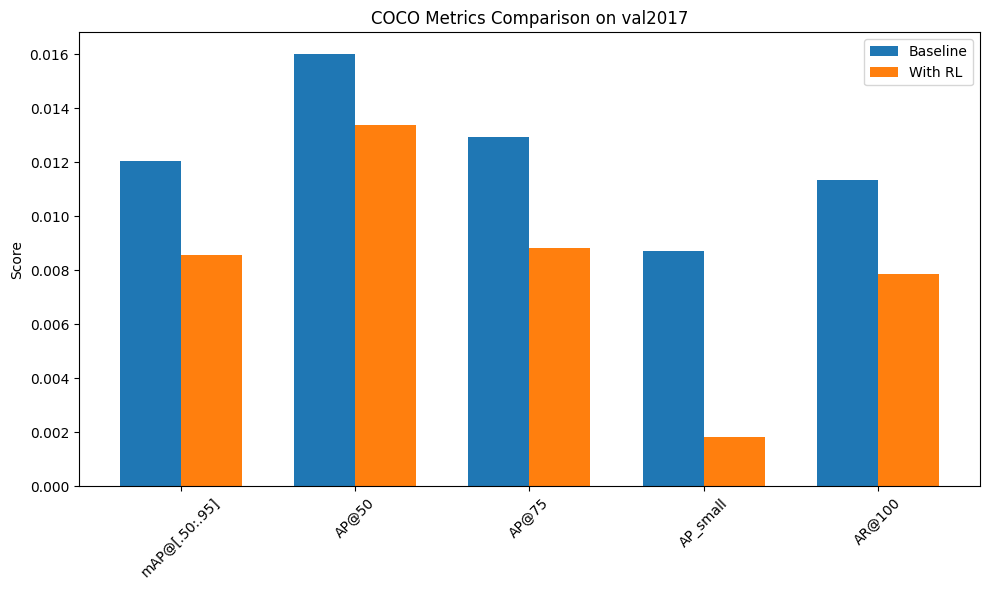

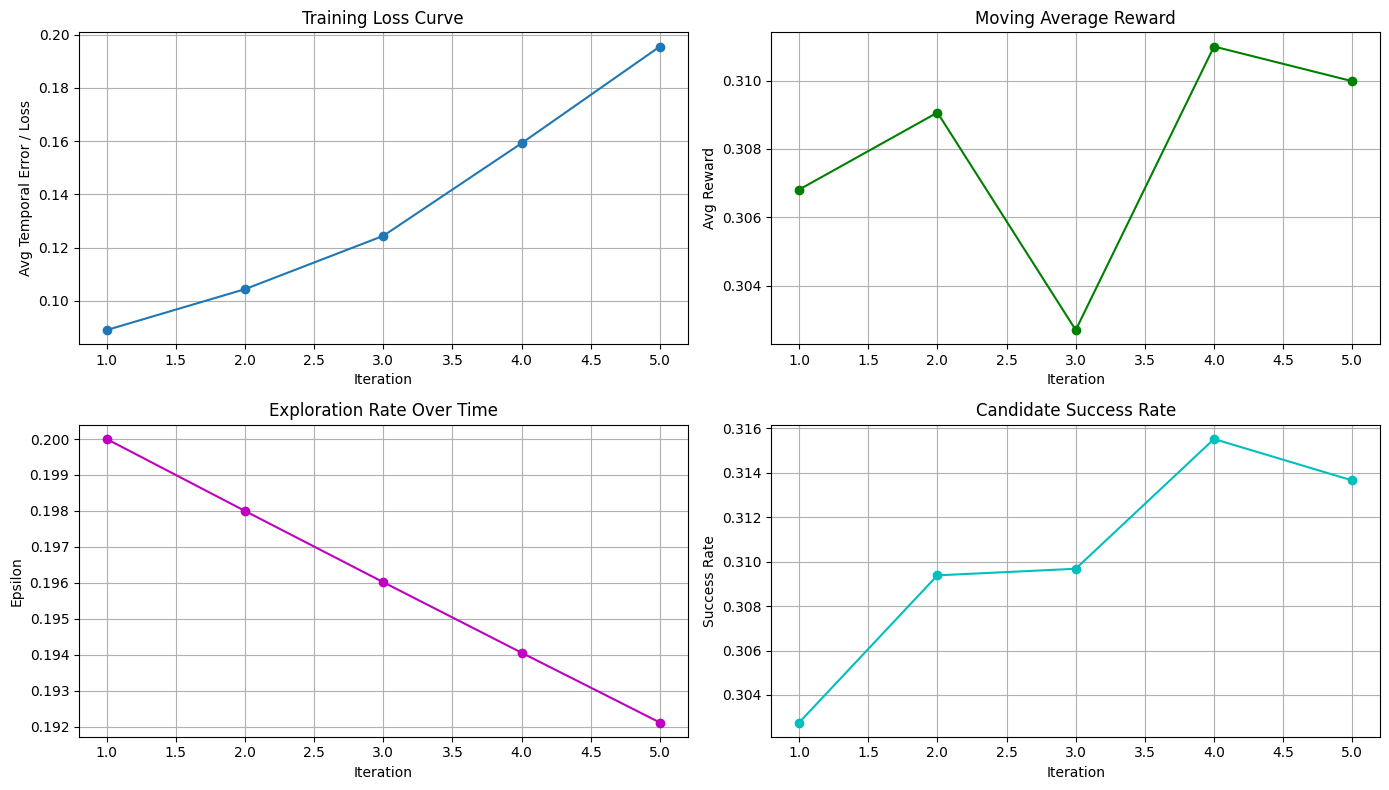

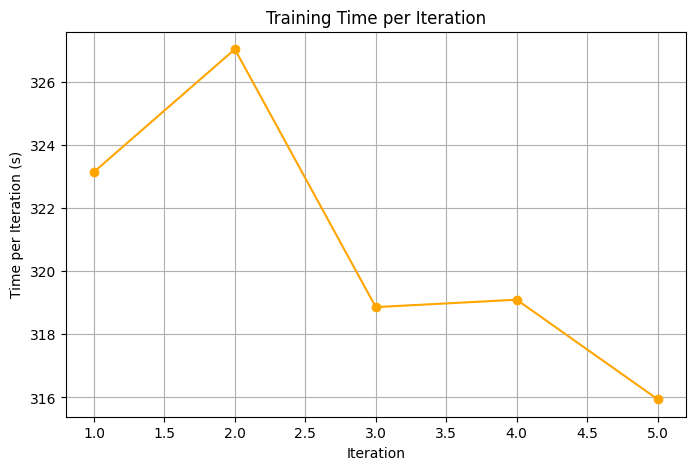

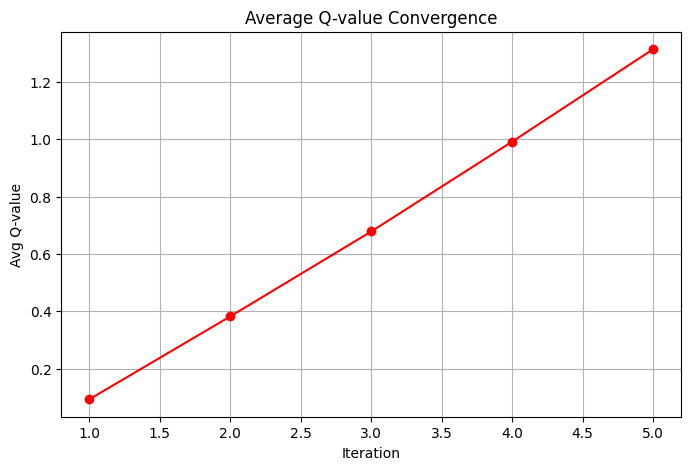

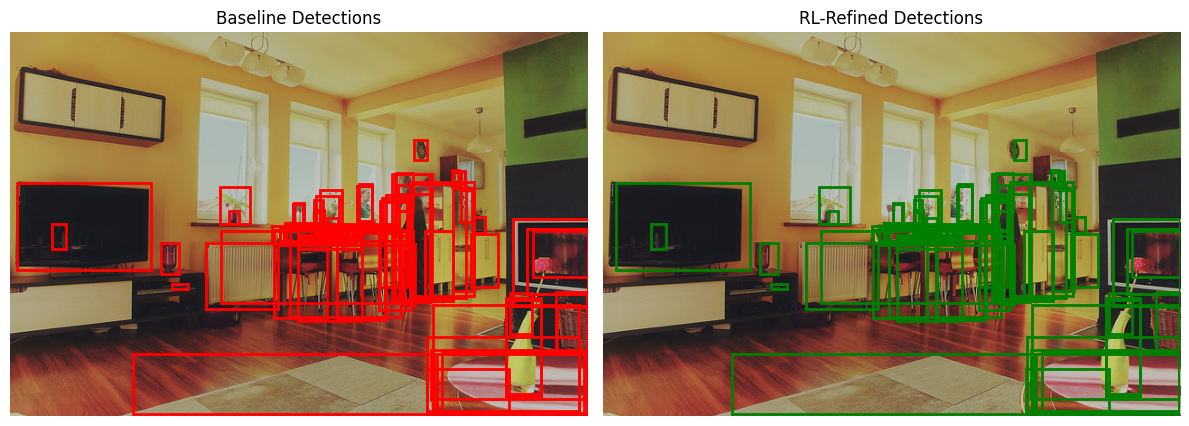

In [10]:
metric_names = ["mAP@[.50:.95]", "AP@50", "AP@75", "AP_small", "AR@100"]
baseline_values = [
    cocoEval_baseline.stats[0],
    cocoEval_baseline.stats[1],
    cocoEval_baseline.stats[2],
    cocoEval_baseline.stats[3],
    cocoEval_baseline.stats[8]
]
rl_values = [
    cocoEval_rl.stats[0],
    cocoEval_rl.stats[1],
    cocoEval_rl.stats[2],
    cocoEval_rl.stats[3],
    cocoEval_rl.stats[8]
]

df_metrics = pd.DataFrame({
    "Metric": metric_names,
    "Baseline": baseline_values,
    "With RL": rl_values,
    "Difference": [rl - base for rl, base in zip(rl_values, baseline_values)]
})
print("\nSummary Metrics Table:")
print(df_metrics)

# Plot bar chart for COCO metrics.
x = np.arange(len(metric_names))
width = 0.35
plt.figure(figsize=(10,6))
plt.bar(x - width/2, baseline_values, width, label='Baseline')
plt.bar(x + width/2, rl_values, width, label='With RL')
plt.ylabel("Score")
plt.title("COCO Metrics Comparison on val2017")
plt.xticks(x, metric_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot training curves.
plt.figure(figsize=(14, 8))
plt.subplot(2,2,1)
plt.plot(range(1, len(training_losses)+1), training_losses, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Avg Temporal Error / Loss")
plt.title("Training Loss Curve")
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(range(1, len(moving_avg_rewards)+1), moving_avg_rewards, marker='o', color='g')
plt.xlabel("Iteration")
plt.ylabel("Avg Reward")
plt.title("Moving Average Reward")
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(range(1, len(exploration_rates)+1), exploration_rates, marker='o', color='m')
plt.xlabel("Iteration")
plt.ylabel("Epsilon")
plt.title("Exploration Rate Over Time")
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(range(1, len(success_rates)+1), success_rates, marker='o', color='c')
plt.xlabel("Iteration")
plt.ylabel("Success Rate")
plt.title("Candidate Success Rate")
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(iteration_times)+1), iteration_times, marker='o', color='orange')
plt.xlabel("Iteration")
plt.ylabel("Time per Iteration (s)")
plt.title("Training Time per Iteration")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(avg_q_values)+1), avg_q_values, marker='o', color='r')
plt.xlabel("Iteration")
plt.ylabel("Avg Q-value")
plt.title("Average Q-value Convergence")
plt.grid(True)
plt.show()

# Qualitative visualization on one validation image.
def visualize_detections(pil_img, detections, color, label):
    plt.imshow(pil_img)
    ax = plt.gca()
    seen = False
    for det in detections:
        x, y, w, h = det["bbox"]
        if not seen:
            rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2, label=label)
            seen = True
        else:
            rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
    plt.axis("off")

sample_img, sample_target = val_dataset[0]
if len(sample_target) > 0 and "image_id" in sample_target[0]:
    sample_img_id = sample_target[0]["image_id"]
else:
    sample_img_id = -1
pil_img = transforms.ToPILImage()(sample_img)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Baseline Detections")
visualize_detections(pil_img, [det for det in results_baseline if det["image_id"]==sample_img_id], "red", "Baseline")
plt.subplot(1,2,2)
plt.title("RL-Refined Detections")
visualize_detections(pil_img, [det for det in results_rl if det["image_id"]==sample_img_id], "green", "RL")
plt.tight_layout()
plt.show()